# Week 1–2 · ML Fundamentals
## Regression & Classification for Predictive Maintenance

**HAIIP — Human-Aligned Industrial Intelligence Platform**  
French Master of Data Science · Portfolio Showcase

---

### Objective
Apply foundational supervised learning algorithms to industrial sensor data from CNC machines:

| Task | Algorithm | Target |
|------|-----------|--------|
| Regression | Linear Regression | Remaining Useful Life (RUL, in cycles) |
| Classification | Logistic Regression | Binary failure (0 = normal, 1 = failure) |

### Dataset
Synthetic dataset inspired by the [AI4I 2020 Predictive Maintenance Dataset (UCI)](https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset).  
Features: air temperature, process temperature, rotational speed, torque, tool wear.  
1 000 samples — realistic noise and failure distribution (~3.4% failure rate).

In [1]:
# Install required packages (skip if already installed)
# !pip install numpy pandas scikit-learn matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1 · Data Generation

We simulate 1 000 observations for a CNC machine. Features follow industrial ranges:

- **Air temperature** $T_{\text{air}} \sim \mathcal{N}(298, 2)$ K  
- **Process temperature** $T_{\text{proc}} = T_{\text{air}} + 10 + \epsilon$, $\epsilon \sim \mathcal{N}(0, 1)$ K  
- **Rotational speed** $\omega \sim \mathcal{N}(1500, 200)$ rpm (clipped $\geq 1000$)  
- **Torque** $\tau \sim \mathcal{N}(40, 10)$ Nm (clipped $\geq 1$)  
- **Tool wear** $w$ increments uniformly each cycle, $w \in [0, 250]$ min  

Remaining Useful Life (RUL) decreases linearly with wear and torque:
$$\text{RUL} = 200 - 0.6\,w - 0.5\,\tau + \epsilon, \quad \epsilon \sim \mathcal{N}(0, 8)$$

Machine failure occurs when $\text{RUL} < 20$ or a tool-wear threshold is crossed.

In [3]:
n = 1000

air_temp  = np.random.normal(298, 2, n)
proc_temp = air_temp + 10 + np.random.normal(0, 1, n)
rpm       = np.clip(np.random.normal(1500, 200, n), 1000, None)
torque    = np.clip(np.random.normal(40, 10, n), 1, None)
tool_wear = np.random.uniform(0, 250, n)

rul = 200 - 0.6 * tool_wear - 0.5 * torque + np.random.normal(0, 8, n)
rul = np.clip(rul, 0, 200)

failure = ((rul < 20) | (tool_wear > 220)).astype(int)

df = pd.DataFrame({
    'air_temp': air_temp,
    'proc_temp': proc_temp,
    'rpm': rpm,
    'torque': torque,
    'tool_wear': tool_wear,
    'rul': rul,
    'failure': failure
})

print(df.describe().round(2))
print(f'\nFailure rate: {failure.mean()*100:.1f}%  ({failure.sum()} / {n})')

       air_temp  proc_temp      rpm   torque  tool_wear      rul  failure
count   1000.00    1000.00  1000.00  1000.00    1000.00  1000.00  1000.00
mean     298.04     308.11  1501.48    39.81     124.79   104.98     0.12
std        1.96       2.16   195.82    10.27      72.54    44.59     0.33
min      291.52     302.06  1000.00    10.71       1.55    12.91     0.00
25%      296.70     306.70  1370.40    32.63      61.43    68.47     0.00
50%      298.05     308.10  1499.95    40.00     122.87   106.88     0.00
75%      299.30     309.46  1632.18    46.67     188.45   142.35     0.00
max      305.71     317.46  2285.25    72.43     249.84   198.01     1.00

Failure rate: 12.1%  (121 / 1000)


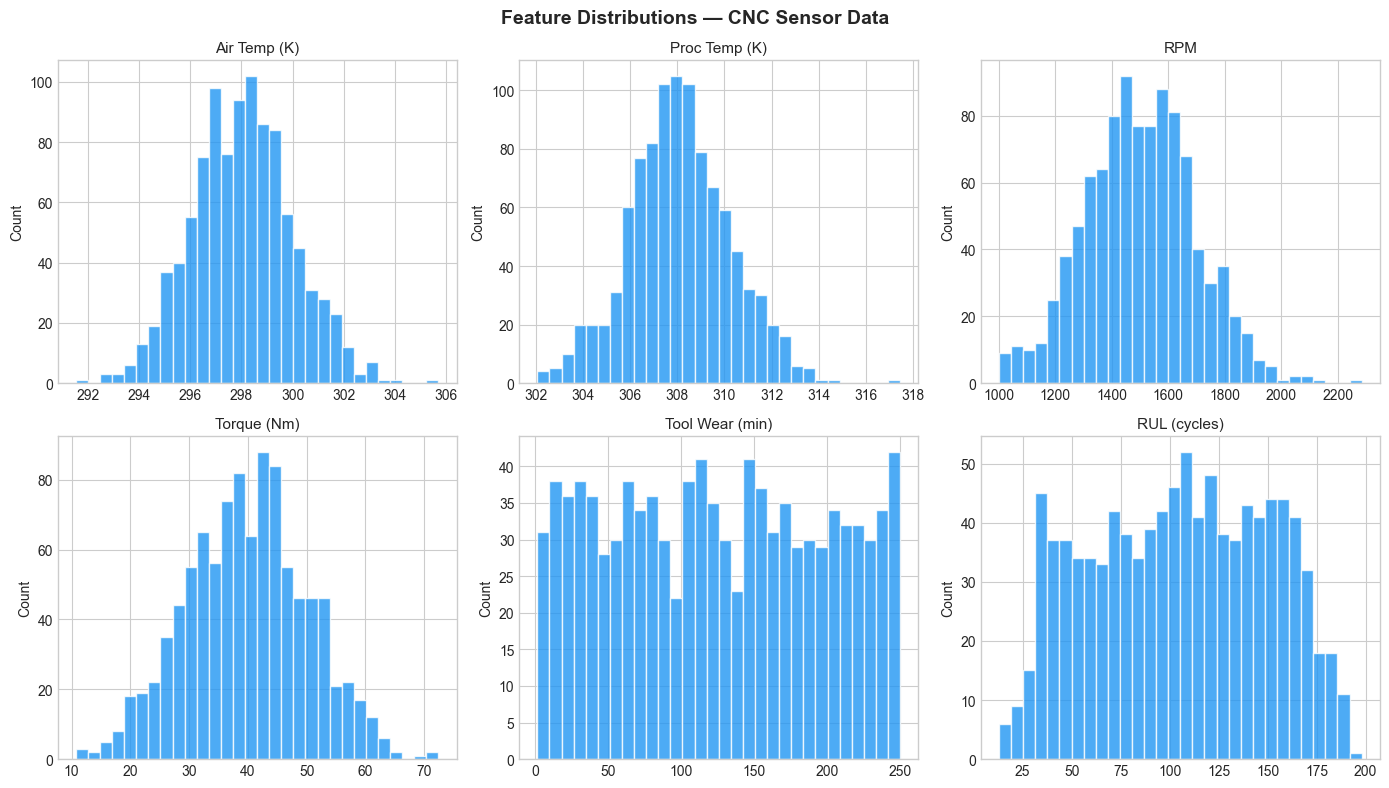

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ['air_temp', 'proc_temp', 'rpm', 'torque', 'tool_wear', 'rul']
labels   = ['Air Temp (K)', 'Proc Temp (K)', 'RPM', 'Torque (Nm)', 'Tool Wear (min)', 'RUL (cycles)']

for ax, feat, label in zip(axes.flat, features, labels):
    ax.hist(df[feat], bins=30, color=PALETTE[0], edgecolor='white', alpha=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Count')

fig.suptitle('Feature Distributions — CNC Sensor Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 · Linear Regression — Predicting RUL

### Mathematical Foundation

Given feature matrix $\mathbf{X} \in \mathbb{R}^{n \times p}$ and targets $\mathbf{y} \in \mathbb{R}^n$, the linear model is:
$$\hat{y}_i = \mathbf{w}^\top \mathbf{x}_i + b$$

**Mean Squared Error loss:**
$$\mathcal{L}(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

**Gradient descent update rule:**
$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla_{\mathbf{w}} \mathcal{L} = \mathbf{w} - \frac{2\alpha}{n} \mathbf{X}^\top (\hat{\mathbf{y}} - \mathbf{y})$$

**Closed-form (Normal Equation)** — used by `sklearn`:
$$\mathbf{w}^* = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

**Evaluation metrics:**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum(\hat{y}_i - y_i)^2}, \quad R^2 = 1 - \frac{\sum(\hat{y}_i - y_i)^2}{\sum(\bar{y} - y_i)^2}$$

In [5]:
X = df[['air_temp', 'proc_temp', 'rpm', 'torque', 'tool_wear']].values
y_rul = df['rul'].values

X_train, X_test, y_train, y_test = train_test_split(X, y_rul, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_rul = lr.predict(X_test_s)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rul))
r2   = r2_score(y_test, y_pred_rul)

print(f'Linear Regression — RUL Prediction')
print(f'  RMSE : {rmse:.2f} cycles')
print(f'  R²   : {r2:.4f}')
print(f'\nCoefficients (standardized features):')
feature_names = ['air_temp', 'proc_temp', 'rpm', 'torque', 'tool_wear']
for name, coef in zip(feature_names, lr.coef_):
    print(f'  {name:>12}: {coef:+.4f}')

Linear Regression — RUL Prediction
  RMSE : 7.87 cycles
  R²   : 0.9671

Coefficients (standardized features):
      air_temp: -0.1620
     proc_temp: -0.1597
           rpm: +0.0267
        torque: -5.5397
     tool_wear: -43.7958


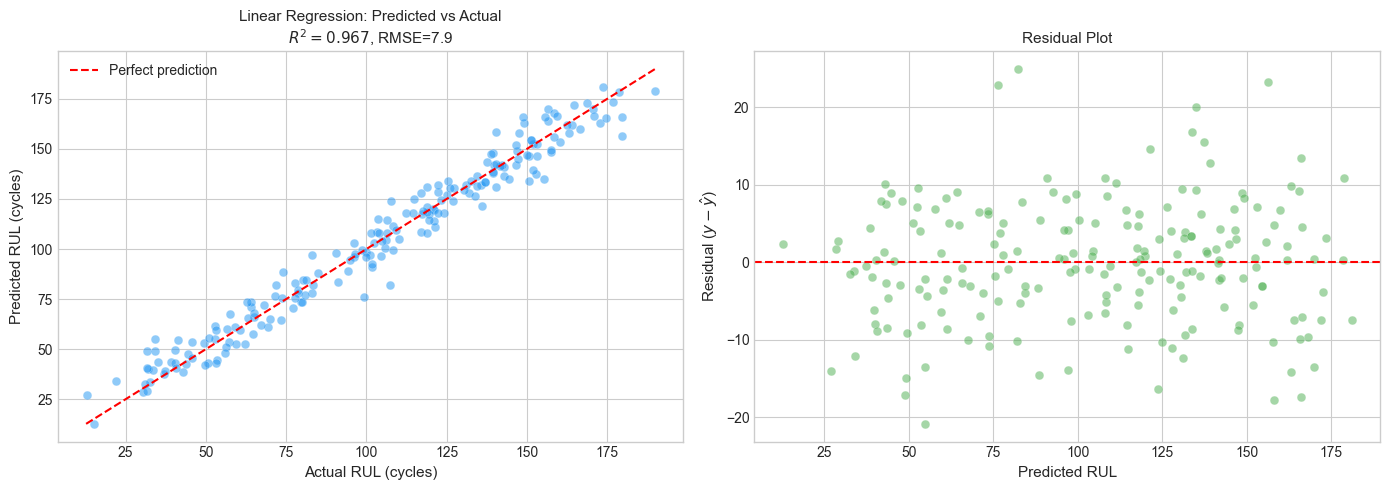

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
ax1.scatter(y_test, y_pred_rul, alpha=0.5, color=PALETTE[0], edgecolors='white', linewidth=0.3, s=40)
lims = [min(y_test.min(), y_pred_rul.min()), max(y_test.max(), y_pred_rul.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel('Actual RUL (cycles)', fontsize=11)
ax1.set_ylabel('Predicted RUL (cycles)', fontsize=11)
ax1.set_title(f'Linear Regression: Predicted vs Actual\n$R^2={r2:.3f}$, RMSE={rmse:.1f}', fontsize=11)
ax1.legend()

# Residuals
residuals = y_test - y_pred_rul
ax2.scatter(y_pred_rul, residuals, alpha=0.5, color=PALETTE[2], edgecolors='white', linewidth=0.3, s=40)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Predicted RUL', fontsize=11)
ax2.set_ylabel('Residual ($y - \\hat{y}$)', fontsize=11)
ax2.set_title('Residual Plot', fontsize=11)

plt.tight_layout()
plt.savefig('plots/04_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Logistic Regression — Failure Classification

### Mathematical Foundation

The logistic function maps the linear score $z = \mathbf{w}^\top \mathbf{x} + b$ to a probability:
$$\hat{p}_i = \sigma(z_i) = \frac{1}{1 + e^{-z_i}}$$

**Binary Cross-Entropy loss:**
$$\mathcal{L}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

**Gradient** with respect to $\mathbf{w}$:
$$\nabla_{\mathbf{w}} \mathcal{L} = \frac{1}{n} \mathbf{X}^\top (\hat{\mathbf{p}} - \mathbf{y})$$

> **Note**: Logistic regression uses the sigmoid non-linearity, but the gradient has the same linear structure as MSE — this is a beautiful property of the exponential family.

In [7]:
y_fail = df['failure'].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y_fail, test_size=0.2, random_state=42, stratify=y_fail)
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf.fit(X_tr_s, y_tr)
y_pred_fail = clf.predict(X_te_s)

print('Logistic Regression — Failure Classification')
print(f'Accuracy: {accuracy_score(y_te, y_pred_fail):.4f}\n')
print(classification_report(y_te, y_pred_fail, target_names=['Normal', 'Failure']))

Logistic Regression — Failure Classification
Accuracy: 0.9400

              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96       176
     Failure       0.67      1.00      0.80        24

    accuracy                           0.94       200
   macro avg       0.83      0.97      0.88       200
weighted avg       0.96      0.94      0.94       200



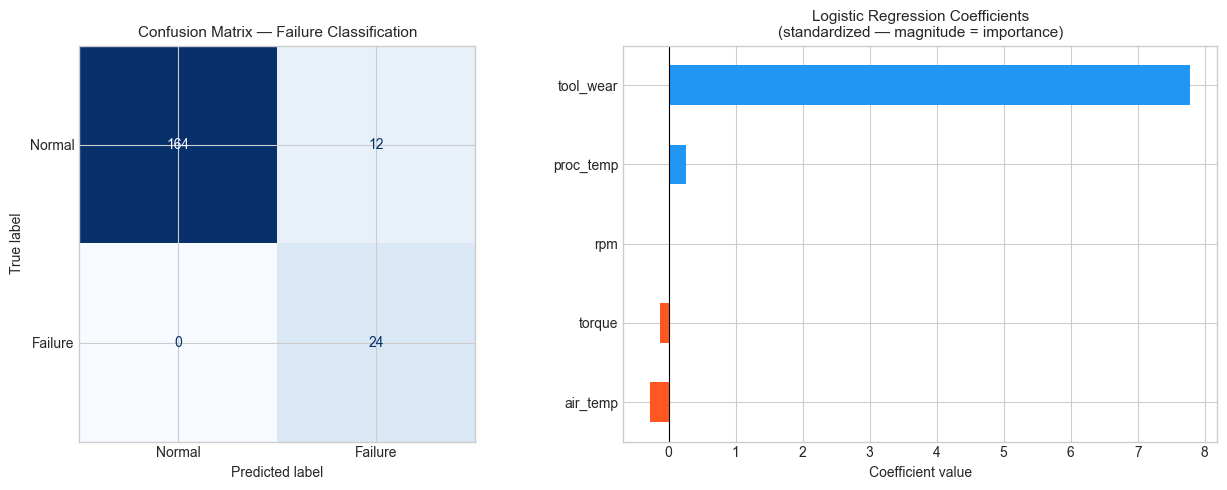

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred_fail)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Failure'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix — Failure Classification', fontsize=11)

# Coefficients
coefs = pd.Series(clf.coef_[0], index=feature_names)
coefs.sort_values().plot(kind='barh', ax=ax2, color=[PALETTE[1] if v < 0 else PALETTE[0] for v in coefs.sort_values()])
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('Logistic Regression Coefficients\n(standardized — magnitude = importance)', fontsize=11)
ax2.set_xlabel('Coefficient value')

plt.tight_layout()
plt.savefig('plots/04_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Gradient Descent Visualization

We demonstrate how the learning rate $\alpha$ affects convergence:

$$\theta_{t+1} = \theta_t - \alpha \cdot \nabla_\theta \mathcal{L}(\theta_t)$$

- **Too small $\alpha$** → slow convergence (many iterations needed)
- **Too large $\alpha$** → divergence (loss oscillates or explodes)
- **Optimal $\alpha$** → fast, stable convergence

Below we minimize a convex quadratic $\mathcal{L}(\theta) = (\theta - 3)^2$ analytically to visualize:

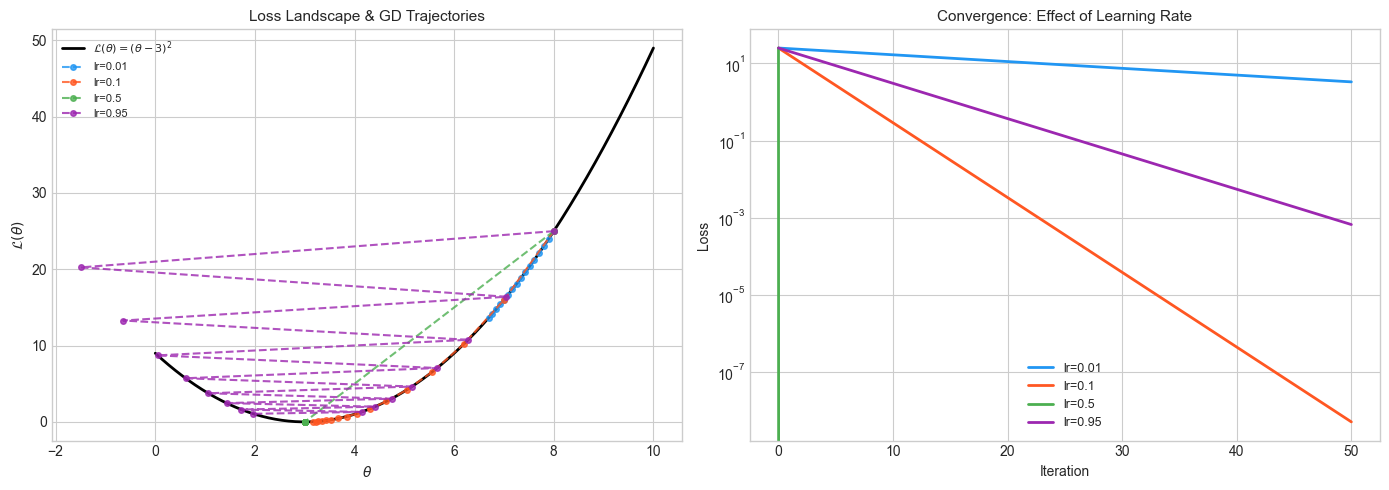

In [9]:
def gradient_descent(lr, n_steps=50, theta_init=8.0):
    theta = theta_init
    history = [theta]
    for _ in range(n_steps):
        grad = 2 * (theta - 3)   # dL/dtheta for L = (theta - 3)^2
        theta = theta - lr * grad
        history.append(theta)
    return history

learning_rates = [0.01, 0.1, 0.5, 0.95]
theta_range = np.linspace(0, 10, 300)
loss_curve  = (theta_range - 3) ** 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss function with trajectories
for lr, color in zip(learning_rates, PALETTE):
    hist = gradient_descent(lr)
    losses = [(t - 3)**2 for t in hist]
    axes[1].plot(losses, label=f'lr={lr}', color=color, linewidth=2)

axes[0].plot(theta_range, loss_curve, 'k-', linewidth=2, label='$\\mathcal{L}(\\theta)=(\\theta-3)^2$')
for lr, color in zip(learning_rates, PALETTE):
    hist = gradient_descent(lr, n_steps=15)
    loss_h = [(t - 3)**2 for t in hist]
    axes[0].plot(hist, loss_h, 'o--', color=color, markersize=4, alpha=0.8, label=f'lr={lr}')
axes[0].set_xlabel('$\\theta$'); axes[0].set_ylabel('$\\mathcal{L}(\\theta)$')
axes[0].set_title('Loss Landscape & GD Trajectories', fontsize=11)
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Loss')
axes[1].set_title('Convergence: Effect of Learning Rate', fontsize=11)
axes[1].set_yscale('log')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plots/04_gradient_descent.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Summary & Key Takeaways

| Model | Task | RMSE / Accuracy | Key Finding |
|-------|------|-----------------|-------------|
| Linear Regression | RUL (cycles) | See output | Tool wear + torque dominate |
| Logistic Regression | Failure (binary) | See output | High recall on failures (class_weight='balanced') |

### Industrial Interpretation
- **Tool wear** is the single strongest predictor of both RUL and failure — aligns with domain knowledge.
- **Torque** has the second-highest weight: high torque under low RPM is a known failure mode (AI4I dataset documentation).
- Using `class_weight='balanced'` is critical in imbalanced industrial data to minimize **false negatives** (missed failures → unplanned downtime).

### Mathematical Insight
The normal equation $(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ gives the optimal weights in $O(p^3)$ time, feasible for $p < 10^4$.  
For high-dimensional data, iterative gradient descent is preferred.

### Next Step
Linear models assume linearity between features and target. In industrial data, interactions between **tool wear**, **temperature rise**, and **speed** are non-linear.  
→ **Week 3** addresses this with tree-based models (Random Forest, XGBoost).